# **Scikit-learn Documentation**

**https://scikit-learn.org/stable/index.html**

#**Python Packages**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

#**Machine Learning On Health Data**

##Dataset with all numerical features and categorical target (binary class)

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = 1000

# Generate synthetic data based on feature descriptions
height = np.random.normal(170, 10, n_samples)    # Height in cm
weight = np.random.normal(70, 15, n_samples)     # Weight in kg
bmi = weight / (height / 100) ** 2               # BMI (kg/m^2)
waist_circumference = np.random.normal(90, 15, n_samples)  # Waist circumference in cm
daily_caloric_intake = np.random.normal(2500, 500, n_samples) # Daily caloric intake in kcal
sedentary_hours_per_day = np.random.normal(8, 2, n_samples)   # Sedentary hours per day
sleep_duration = np.random.normal(7, 1.5, n_samples)          # Sleep duration in hours
blood_pressure = np.random.normal(120, 15, n_samples)         # Blood pressure in mmHg

# Assign labels based on BMI threshold (simplified rule for obesity)
labels = np.where(bmi > 30, 'obese', 'not obese')

# Create a DataFrame
df_health = pd.DataFrame({
    'Height': height,
    'Weight': weight,
    'BMI': bmi,
    'Waist Circumference': waist_circumference,
    'Daily Caloric Intake': daily_caloric_intake,
    'Sedentary Hours per Day': sedentary_hours_per_day,
    'Sleep Duration': sleep_duration,
    'Blood Pressure': blood_pressure,
    'Label': labels
})

In [ ]:
df_health.head()

,Height,Weight,BMI,Waist Circumference,Daily Caloric Intake,Sedentary Hours per Day,Sleep Duration,Blood Pressure,Label
0,174.967142,90.990332,29.722289,79.872326,1546.096221,6.273013,6.364360,103.288780,not obese
1,168.617357,83.869505,29.498472,87.832220,2069.807495,7.937593,6.319879,110.536037,not obese
2,176.476885,70.894456,22.763373,78.113701,2293.197233,8.036034,4.306535,105.869097,not obese
3,185.230299,60.295948,17.573735,85.380577,3443.843829,8.945261,6.504865,111.780063,not obese
4,167.658466,80.473350,28.628665,61.595780,2778.276562,5.266283,8.099244,116.787745,not obese


##Visualizing the data distibution

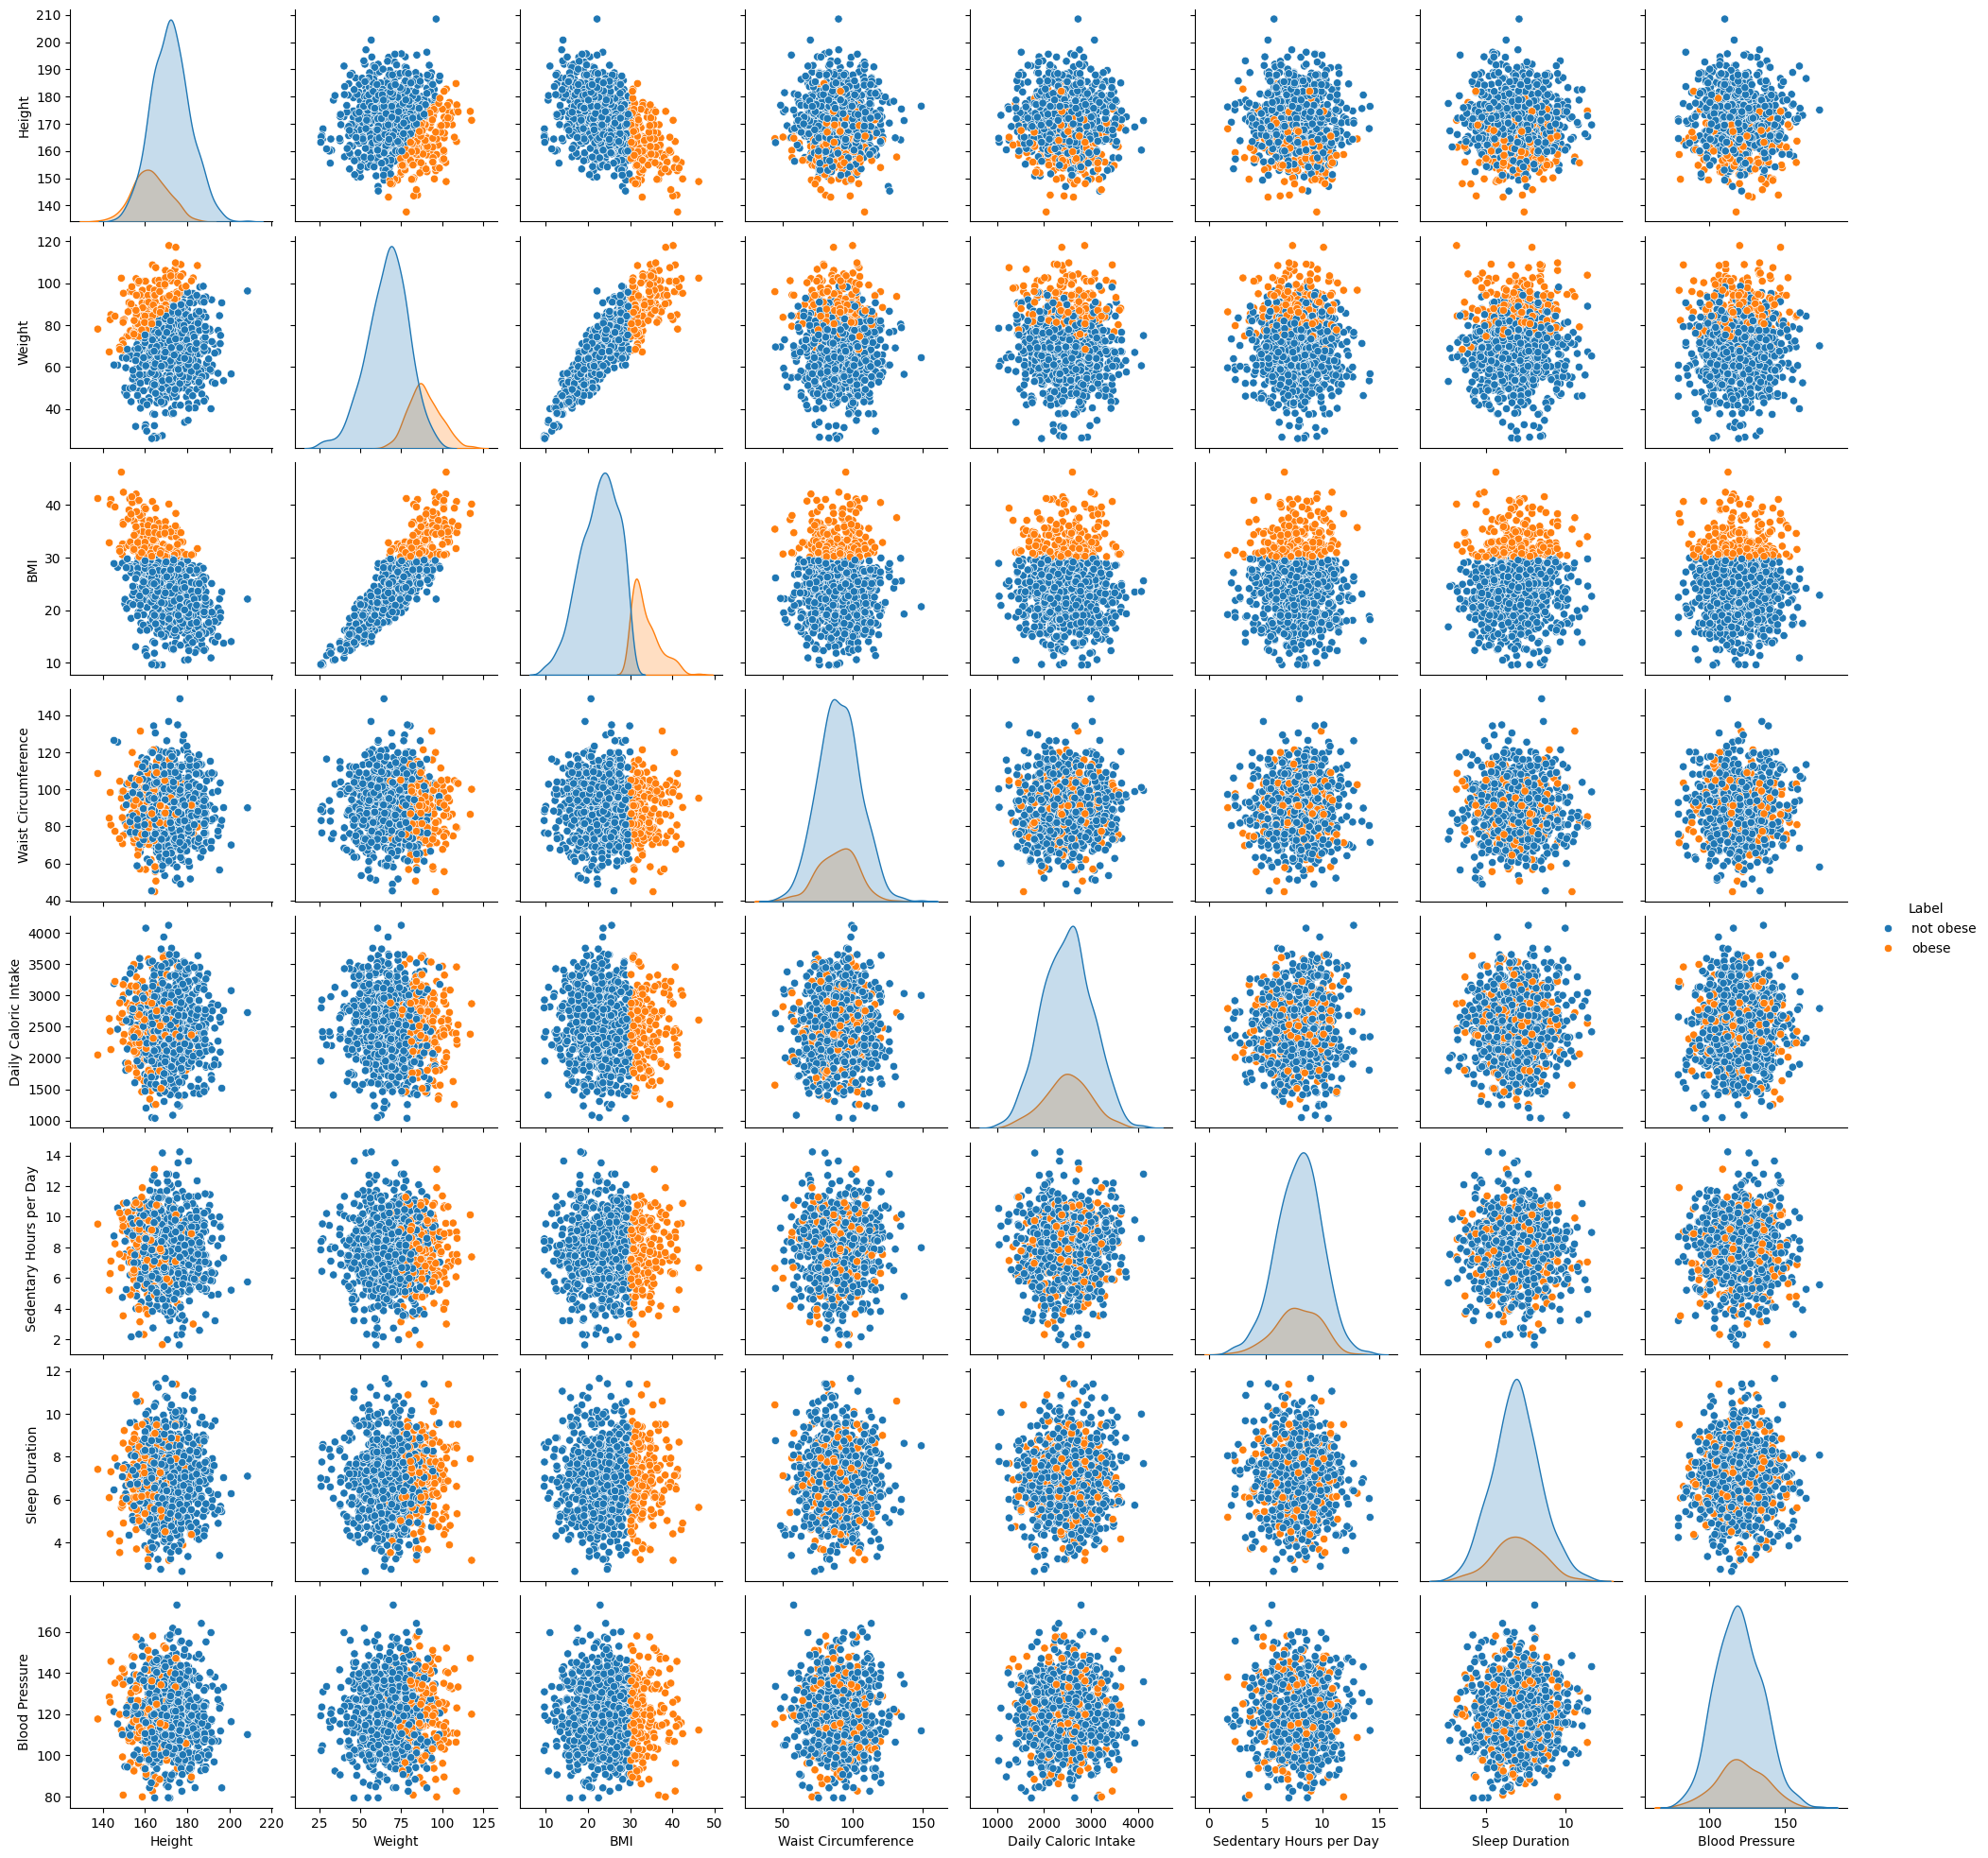

In [ ]:
#plot distribution of all features in data
sns.pairplot(df_health, hue='Label')

<Axes: xlabel='Label', ylabel='count'>

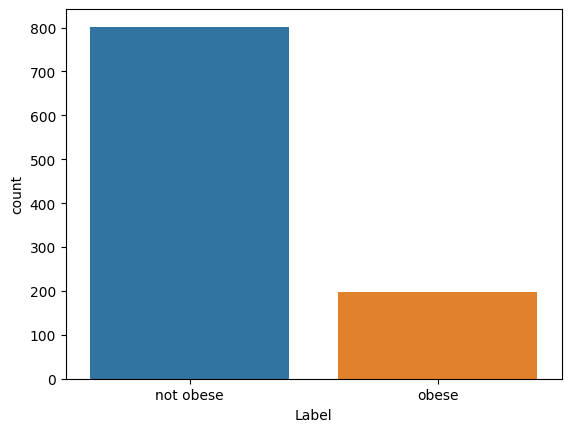

In [ ]:
#plot the counts of label
sns.countplot(x='Label', data=df_health,hue='Label')

##Creating Features and Target Variable data frames

In [ ]:
X = df_health.drop('Label', axis=1)
y = df_health['Label']

##Feature Engineering (Scaling/Encoding)

1.   Min/Max or Standardize scaling for numerical features
2.   Encoding for categorical feature (In this case target variable)



In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Height                   1000 non-null   float64
 1   Weight                   1000 non-null   float64
 2   BMI                      1000 non-null   float64
 3   Waist Circumference      1000 non-null   float64
 4   Daily Caloric Intake     1000 non-null   float64
 5   Sedentary Hours per Day  1000 non-null   float64
 6   Sleep Duration           1000 non-null   float64
 7   Blood Pressure           1000 non-null   float64
dtypes: float64(8)
memory usage: 62.6 KB


In [ ]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: Label
Non-Null Count  Dtype 
--------------  ----- 
1000 non-null   object
dtypes: object(1)
memory usage: 7.9+ KB


In [ ]:
#scale numerical features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#scale target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

##Spliting data into training and testing

In [ ]:
#split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y_encoded, test_size=0.2, random_state=42)

##KNN - Classifier

**Identify best values of k between 1 to 30**

Visualizing Bias and varaince Tradeoff

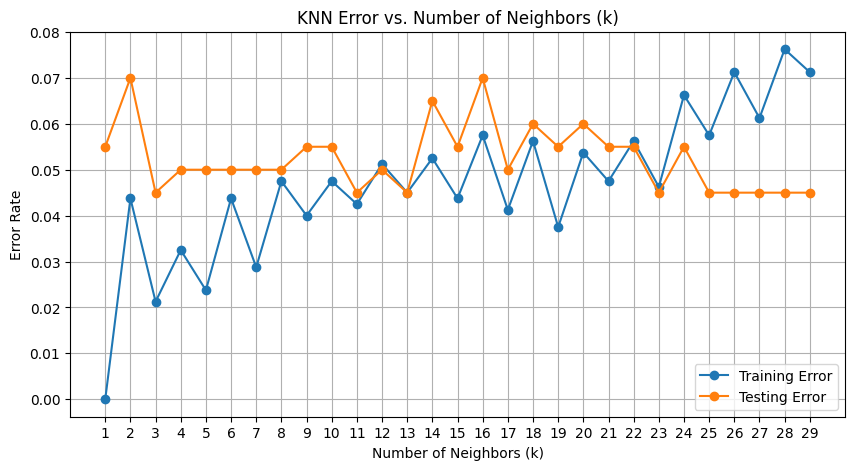

In [ ]:
# Initialize lists to store the errors
k_values = range(1, 30)
train_errors = []
test_errors = []

# Iterate over k values
for k in k_values:
    # Create and fit the KNN model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Predict on training and testing sets
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate the accuracy and errors
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Append the error (1 - accuracy)
    train_errors.append(1 - train_accuracy)
    test_errors.append(1 - test_accuracy)

# Plotting the errors
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_errors, label='Training Error', marker='o')
plt.plot(k_values, test_errors, label='Testing Error', marker='o')
plt.title('KNN Error vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Error Rate')
plt.xticks(k_values)
plt.legend()
plt.grid()
plt.show()


Visualizing accuracies

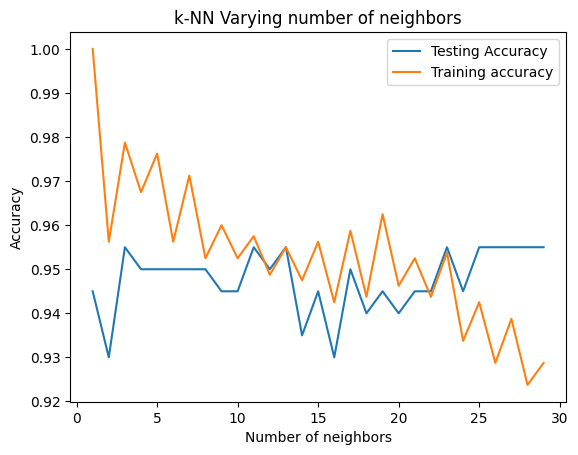

In [ ]:
#Setup arrays to store training and test accuracies
neighbors = np.arange(1,30)
train_accuracy =np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

for i,k in enumerate(neighbors):
    #Setup a knn classifier with k neighbors
    knn = KNeighborsClassifier(n_neighbors=k)

    #Fit the model
    knn.fit(X_train, y_train)

    #Compute accuracy on the training set
    train_accuracy[i] = knn.score(X_train, y_train)

    #Compute accuracy on the test set
    test_accuracy[i] = knn.score(X_test, y_test)

#plot accuracies
plt.title('k-NN Varying number of neighbors')
plt.plot(neighbors, test_accuracy, label='Testing Accuracy')
plt.plot(neighbors, train_accuracy, label='Training accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')
plt.show()

**From the graph, at 3 neigbours the training and testing accuracy seems good. Apply KNN With 3-Neighbours**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

**Test the classifier**

In [ ]:
y_pred = knn.predict(X_test)

**Calculate accuracy**

In [ ]:
accuracy_1=accuracy_score(y_test, y_pred)*100
print(f'Accuracy with 3 neigbour : {accuracy_1} %')

Accuracy with 3 neigbour : 95.5 %


**Create confusion matrix manually**


In [ ]:
pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'], margins=True)

Predicted,0,1,All
Actual,,,
0,162,5,167
1,4,29,33
All,166,34,200


**Create confusion matrix with scikit-learn**

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[162,   5],
       [  4,  29]])

**Visualize confusion matrix**

Text(50.722222222222214, 0.5, 'Actual')

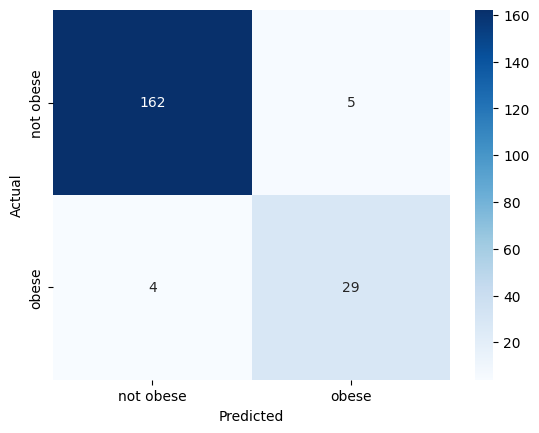

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=df_health['Label'].sort_values().unique(), yticklabels=df_health['Label'].sort_values().unique())
plt.xlabel('Predicted')
plt.ylabel('Actual')

**Create classification report**

In [ ]:
#create classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       167
           1       0.85      0.88      0.87        33

    accuracy                           0.95       200
   macro avg       0.91      0.92      0.92       200
weighted avg       0.96      0.95      0.96       200



**Hyperparameter Tuning (Optimization)**

So we have 1000 data points, taking square root to get max numbers of neighbour to avoid overfitting and underfitting

In [ ]:
#In case of classifier like knn the parameter to be tuned is n_neighbors
param_grid = {'n_neighbors':np.arange(1,30)}

In [ ]:
knn = KNeighborsClassifier()
knn_cv= GridSearchCV(knn,param_grid,cv=10)
knn_cv.fit(X_scaled,y_encoded)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])})

In [ ]:
print(f'Best Accuracy {(knn_cv.best_score_)*100:.02f} %')

Best Accuracy 95.20 %


In [ ]:
print(f'Best value of k {knn_cv.best_params_}')

Best value of k {'n_neighbors': 3}


**Out of sample testing or Deployment to production (New data provided to algorithm)**

In [ ]:
# Provide new data
new_data = pd.DataFrame({
    'Height': [170],               # in cm
    'Weight': [70],                # in kg
    'BMI': [24.2],                 # Body Mass Index
    'Waist Circumference': [85],   # in cm
    'Daily Caloric Intake': [2000], # in kcal
    'Sedentary Hours per Day': [8], # in hours
    'Sleep Duration': [7],         # in hours
    'Blood Pressure': [120]
})

new_data


,Height,Weight,BMI,Waist Circumference,Daily Caloric Intake,Sedentary Hours per Day,Sleep Duration,Blood Pressure
0,170,70,24.2,85,2000,8,7,120


In [ ]:
features=df_health[['Height', 'Weight', 'BMI', 'Waist Circumference', 'Daily Caloric Intake', 'Sedentary Hours per Day', 'Sleep Duration', 'Blood Pressure']]

In [ ]:
new_data=pd.concat([new_data,features],axis=0)

In [ ]:
# Define transformations for each column type
preprocessor = ColumnTransformer(
    transformers=[
        ('num',MinMaxScaler(), new_data.columns),  # Scaling numeric columns
    ])

# Apply transformations to the DataFrame
transformed_data = preprocessor.fit_transform(new_data)

# Convert the transformed data to a DataFrame
transformed_df = pd.DataFrame(
    transformed_data,
    columns=(preprocessor.named_transformers_['num'].get_feature_names_out(new_data.columns).tolist()
))

In [ ]:
new_prediction = knn_cv.predict(transformed_df.iloc[[0]])

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [ ]:
if(new_prediction[0]==1):
  print('The person is obese')
else:
  print('The person is not obese')

The person is not obese


## Naive Bayes

Calculating prior probabilities

In [ ]:
#class obese probability
p_obs=df_health['Label'].value_counts()['obese']/len(df_health)

In [ ]:
#class not obese probabilty
p_not_obs=df_health['Label'].value_counts()['not obese']/len(df_health)

Training naive bayes classifier (as all features are continuous, use gausian naive baye, or you can transform all features to categorical and then apply multinomial naive bayes)

In [ ]:
#train gausian naive bayes, with prior probabilties and smothing
gnb = GaussianNB(priors=[p_obs,p_not_obs], var_smoothing=1e-9)
gnb.fit(X_train, y_train)

GaussianNB(priors=[0.198, 0.802])

In [ ]:
#test the classifier
y_pred = gnb.predict(X_test)

In [ ]:
#create classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.85      0.92       167
           1       0.57      1.00      0.73        33

    accuracy                           0.88       200
   macro avg       0.78      0.93      0.82       200
weighted avg       0.93      0.88      0.89       200



<Axes: >

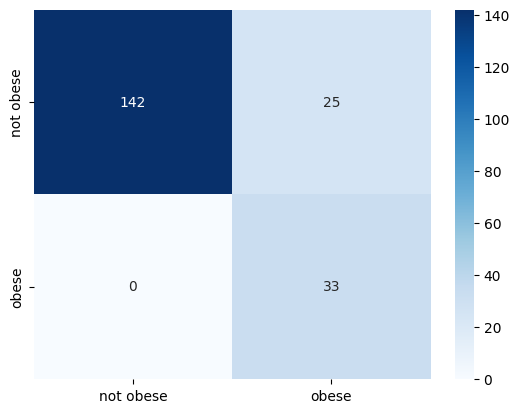

In [ ]:
#visaulize confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=df_health['Label'].sort_values().unique(), yticklabels=df_health['Label'].sort_values().unique())

In [ ]:
#hyperparameter tuning and identify the best model
param_grid = {'var_smoothing': np.logspace(0,-9, num=100)}
nb_cv = GridSearchCV(GaussianNB(), param_grid, cv=10)
nb_cv.fit(X_scaled,y_encoded)

# Get the best smoothing parameter
best_c = nb_cv.best_params_['var_smoothing']
best_acc=nb_cv.best_score_*100
print(f'Best smoothing parameter: {best_c}')
print(f'Best accuracy score:{best_acc}')

Best smoothing parameter: 0.43287612810830584
Best accuracy score:98.80000000000001


Out of sample testing

In [ ]:
new_prediction_nb = nb_cv.predict(transformed_df.iloc[[0]])

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


In [ ]:
if(new_prediction[0]==1):
  print('The person is obese')
else:
  print('The person is not obese')

The person is not obese


## Decision Tree

#### Train, Evaluate and optimize Decision Tree (Variant1: With BMI)

**Train decision tree**

In [ ]:
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
#get the depth of decision tree
print("Tree Depth:", dt.get_depth())
print("Number of Leaves:", dt.get_n_leaves())

Tree Depth: 1
Number of Leaves: 2


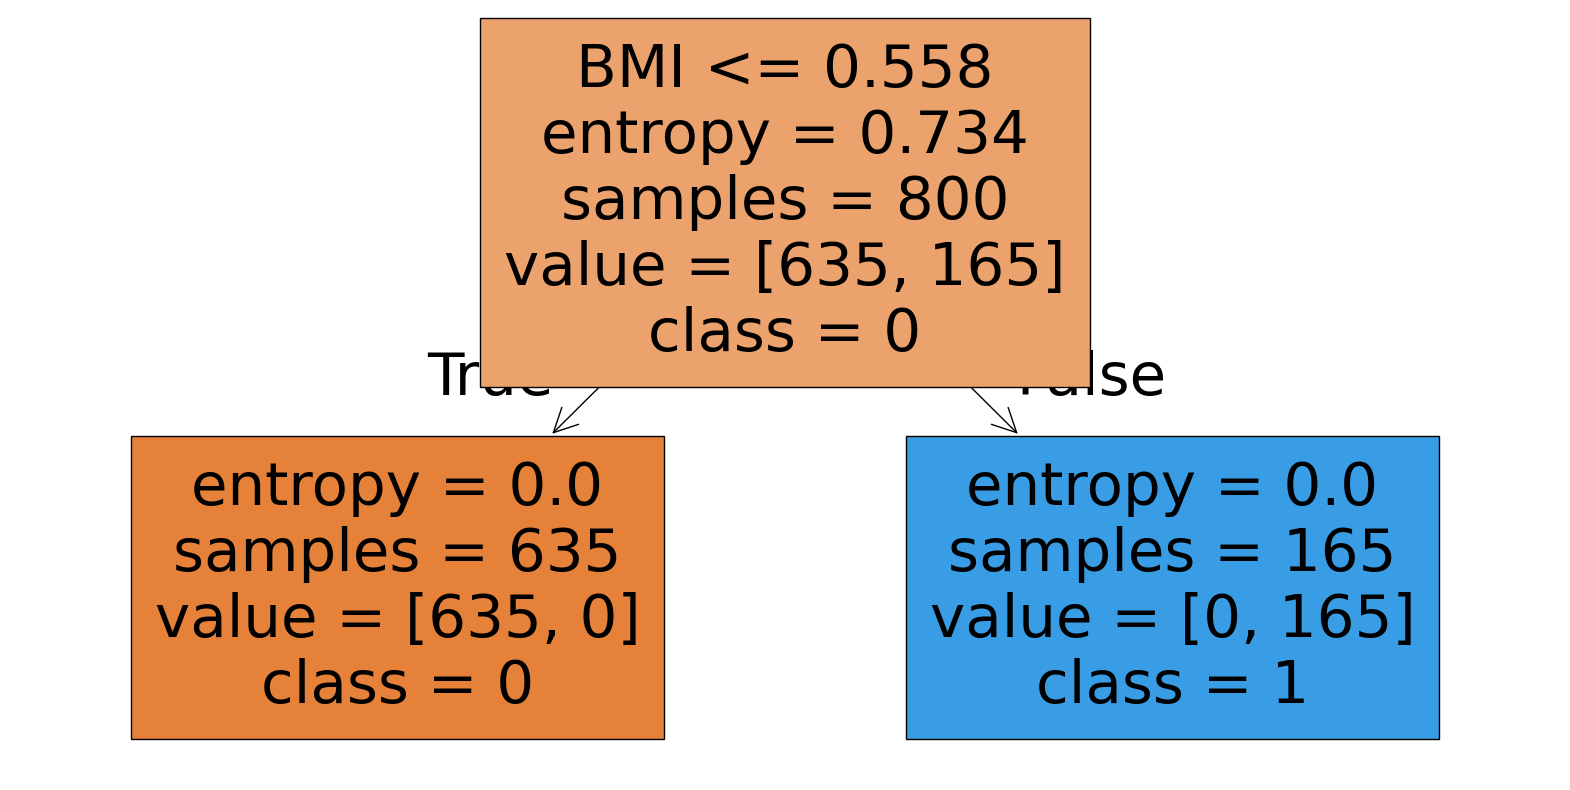

In [ ]:
#visualize the decision tree
plt.figure(figsize=(20,10))
class_names_str = [str(x) for x in dt.classes_]
#list of features in data
feature_names_str = [str(x) for x in X.columns]
plot_tree(dt, feature_names=feature_names_str, class_names=class_names_str, filled=True)
plt.show()

**Evaluate the decision tree**

In [ ]:
#test the classifier
y_pred = dt.predict(X_test)

In [ ]:
#create classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       167
           1       1.00      1.00      1.00        33

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



**Remarks :**


1.   So decision tree is not growing up.
2.   Anyone One feature is early stoping the decision tree.
3.   In this case, BMI could be that feature.
2.   As we know BMI is results of height and weight, so try decsion tree without BMI





#### Train, Evaluate and optimize Decision Tree (Variant2: Without BMI)

In [ ]:
#drop bmi from training data
X_train=pd.DataFrame(X_train, columns=X.columns)
X_test=pd.DataFrame(X_test, columns=X.columns)
X_train_without_bmi=X_train.drop(columns=['BMI'])
X_test_without_bmi=X_test.drop(columns=['BMI'])

**Train decision tree**

In [ ]:
dt_wo_bmi= DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_wo_bmi.fit(X_train_without_bmi, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
#get the depth of decision tree
print("Tree Depth:", dt_wo_bmi.get_depth())
print("Number of Leaves:", dt_wo_bmi.get_n_leaves())

Tree Depth: 7
Number of Leaves: 17


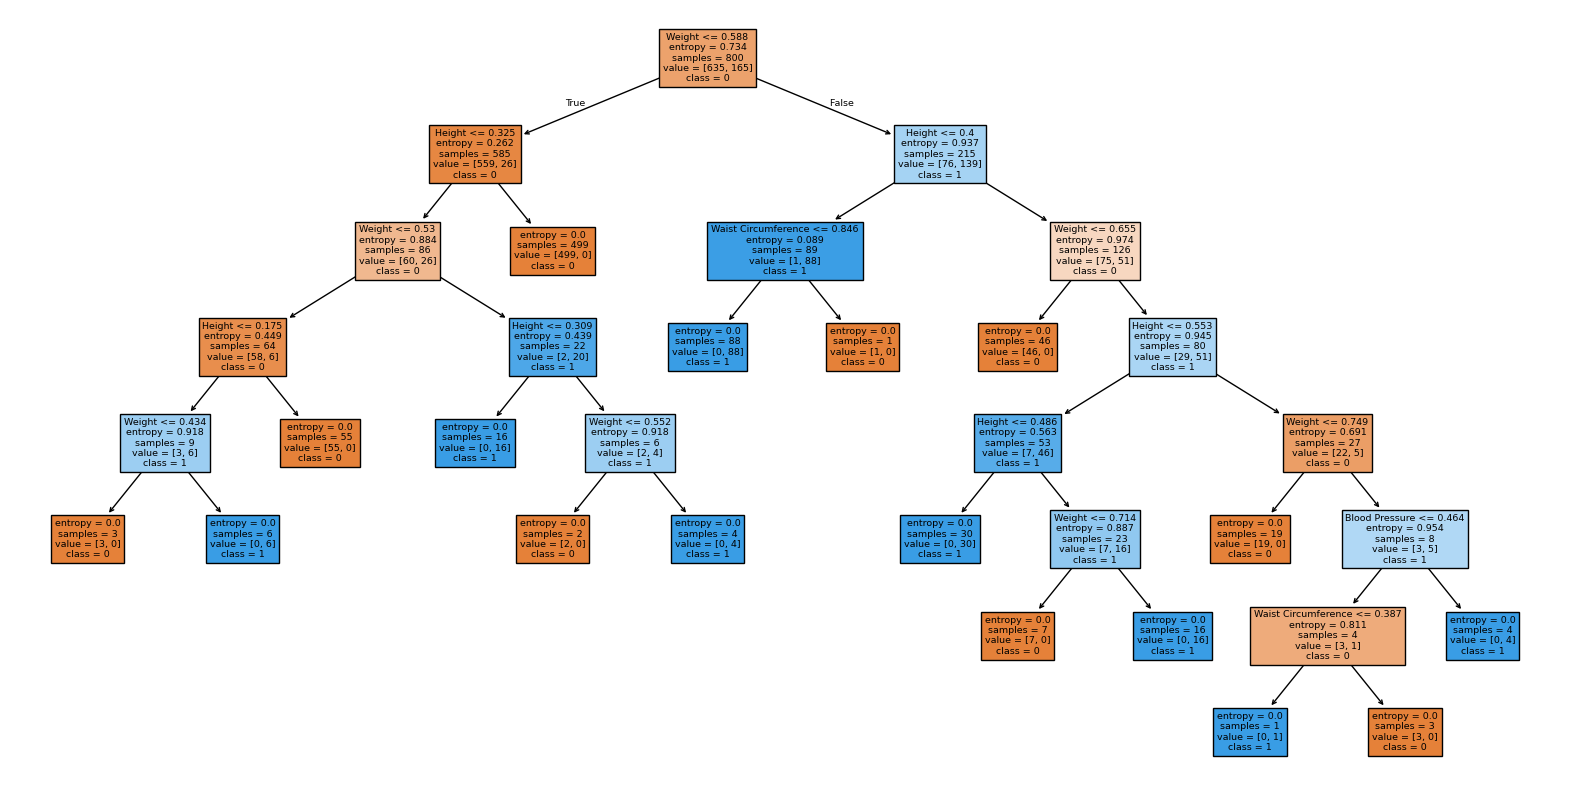

In [ ]:
#visualize the decision tree
plt.figure(figsize=(20,10))
class_names_str = [str(x) for x in dt_wo_bmi.classes_]
#list of features in data
feature_names_str = [str(x) for x in X_train_without_bmi.columns]
plot_tree(dt_wo_bmi, feature_names=feature_names_str, class_names=class_names_str, filled=True)
plt.show()

**Evaluate the decision tree**

In [ ]:
#test the classifier
y_pred = dt_wo_bmi.predict(X_test_without_bmi)

In [ ]:
#create classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       167
           1       0.91      0.88      0.89        33

    accuracy                           0.96       200
   macro avg       0.94      0.93      0.94       200
weighted avg       0.96      0.96      0.96       200



**Optimize Decision tree**

In [ ]:
# Define parameter grid
param_grid = {
    'max_depth': [7, 10, 20, 30, 40, 50],            # Depth of the tree
    'criterion': ['entropy']                   # Split quality criterion
}

In [ ]:
# Initialize the model
dt_model_wo_bmi = DecisionTreeClassifier(random_state=42)

# Set up GridSearchCV
grid_search_wo_bmi = GridSearchCV(
    estimator=dt_model_wo_bmi,
    param_grid=param_grid,
    scoring='accuracy',          # Use accuracy as the scoring metric; change if needed
    cv=10,                        # 5-fold cross-validation
)

In [ ]:
# Fit the grid search
grid_search_wo_bmi.fit(X_train_without_bmi, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['entropy'],
                         'max_depth': [7, 10, 20, 30, 40, 50]},
             scoring='accuracy')

In [ ]:
# Display best parameters and the best score
print("Best Hyperparameters:", grid_search_wo_bmi.best_params_)
print("Best Cross-Validation Score:", (grid_search_wo_bmi.best_score_)*100)

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 7}
Best Cross-Validation Score: 97.24999999999999


## Logistic Regression

In [ ]:
# Initialize logistic regression model
log_reg = LogisticRegression()

# Train the model
log_reg.fit(X_train, y_train)

LogisticRegression()

In [ ]:
#test the classifier
y_pred = log_reg.predict(X_test)

In [ ]:
#create classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       167
           1       1.00      0.73      0.84        33

    accuracy                           0.95       200
   macro avg       0.97      0.86      0.91       200
weighted avg       0.96      0.95      0.95       200



Text(50.722222222222214, 0.5, 'Actual')

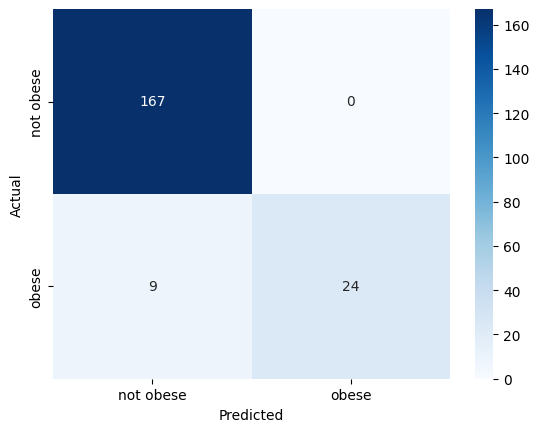

In [ ]:
#visaulize confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=df_health['Label'].sort_values().unique(), yticklabels=df_health['Label'].sort_values().unique())
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [ ]:
#hyperparameter tuning

# Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'solver': ['liblinear', 'lbfgs'],  # Solvers
    'penalty': ['l2'],  # Penalty for regularization
    'max_iter': [100, 200, 300]  # Maximum number of iterations
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=LogisticRegression(), param_grid=param_grid, cv=10, scoring='accuracy')

# Fit grid search
grid_search.fit(X_scaled, y_encoded)

# Get best parameters
best_params = grid_search.best_params_
print(f'Best Parameters: {best_params}')

# Train final model with best parameters
optimized_log_reg = LogisticRegression(**best_params)
optimized_log_reg.fit(X_train, y_train)

# Predict on test set with optimized model
y_pred_optimized = optimized_log_reg.predict(X_test)

Best Parameters: {'C': 100, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}


In [ ]:
#create classification report
print(classification_report(y_test,y_pred_optimized))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       167
           1       1.00      0.97      0.98        33

    accuracy                           0.99       200
   macro avg       1.00      0.98      0.99       200
weighted avg       1.00      0.99      0.99       200



Text(50.722222222222214, 0.5, 'Actual')

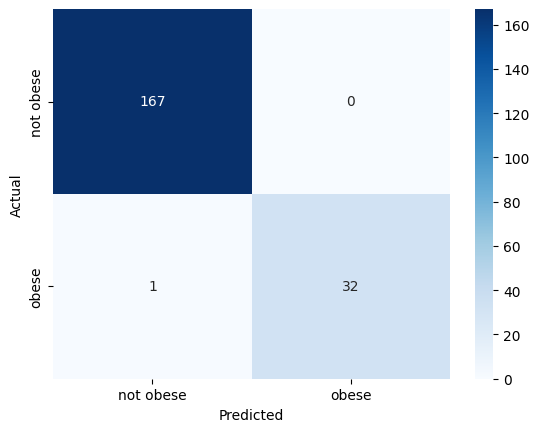

In [ ]:
#visaulize confusion matrix
cm = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=df_health['Label'].sort_values().unique(), yticklabels=df_health['Label'].sort_values().unique())
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [ ]:
#predicting probabilities
y_proba_optimized_no = optimized_log_reg.predict_proba(X_test)[:, 0]
y_proba_optimized_yes = optimized_log_reg.predict_proba(X_test)[:, 1]

In [ ]:
#create data with actual vs predicted and probabilities
data_prob=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred_optimized, 'Probability_not_obese':y_proba_optimized_no, 'Probability_obese':y_proba_optimized_yes})
#convert exponents to float
data_prob['Probability_not_obese'] =data_prob['Probability_not_obese'].apply(lambda x: f"{x:.2f}")
data_prob['Probability_obese'] =data_prob['Probability_obese'].apply(lambda x: f"{x:.2f}")
data_prob.head()

,Actual,Predicted,Probability_not_obese,Probability_obese
0,0,0,1.00,0.00
1,0,0,1.00,0.00
2,0,0,0.76,0.24
3,1,1,0.00,1.00
4,1,1,0.20,0.80


## Handling Class Imbalance problem

In [ ]:
#Using SMOTE To increase minority class representation
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
#create data to check the size of oversampled data and actual data
X_samp=pd.DataFrame(X_resampled, columns=X.columns)
print(f'Size of oversampled data {X_samp.shape}')
print(f'Size of actual data {X_train.shape}')

Size of oversampled data (1270, 8)
Size of actual data (800, 8)


Now you can train model on oversampled data just like the training on train data and check if there is any benefit of using sampling technique

#**Machine Learning On Student Performance Data**

## Dataset with mix of numerical and categorical features with categorical target (Binary Class)

In [ ]:
# Define the dataset size
num_records = 1000

# Define possible values for each categorical variable
gender_choices = ["Male", "Female"]
attendance_choices = ["High", "Medium", "Low"]
parent_education_choices = ["High School", "College", "Graduate"]
extracurricular_choices = ["Yes", "No"]
school_type_choices = ["Public", "Private"]

# Generate random data for each column
data = {
    "Gender": [np.random.choice(gender_choices) for _ in range(num_records)],
    "Age": [np.random.randint(15, 18) for _ in range(num_records)],
    "Study_Hours": [np.random.randint(5, 25) for _ in range(num_records)],
    "Attendance": [np.random.choice(attendance_choices) for _ in range(num_records)],
    "Parent_Education": [np.random.choice(parent_education_choices) for _ in range(num_records)],
    "Extracurricular_Activities": [np.random.choice(extracurricular_choices) for _ in range(num_records)],
    "Marks": [np.random.randint(40, 100) for _ in range(num_records)],
    "School_Type": [np.random.choice(school_type_choices) for _ in range(num_records)],
}

# Create Pass/Fail outcome based on Marks
data["Label"] = ["Pass" if marks >= 60 else "Fail" for marks in data["Marks"]]

# Convert the data dictionary into a DataFrame
df_students = pd.DataFrame(data)

# Display the first few rows of the DataFrame
df_students.head()


,Gender,Age,Study_Hours,Attendance,Parent_Education,Extracurricular_Activities,Marks,School_Type,Label
0,Male,16,24,High,High School,Yes,45,Private,Fail
1,Female,17,17,High,Graduate,Yes,86,Private,Pass
2,Male,15,24,Medium,College,Yes,56,Public,Fail
3,Male,16,6,Low,College,Yes,43,Public,Fail
4,Male,17,7,Low,High School,Yes,61,Private,Pass


##Visualizing the data distibution

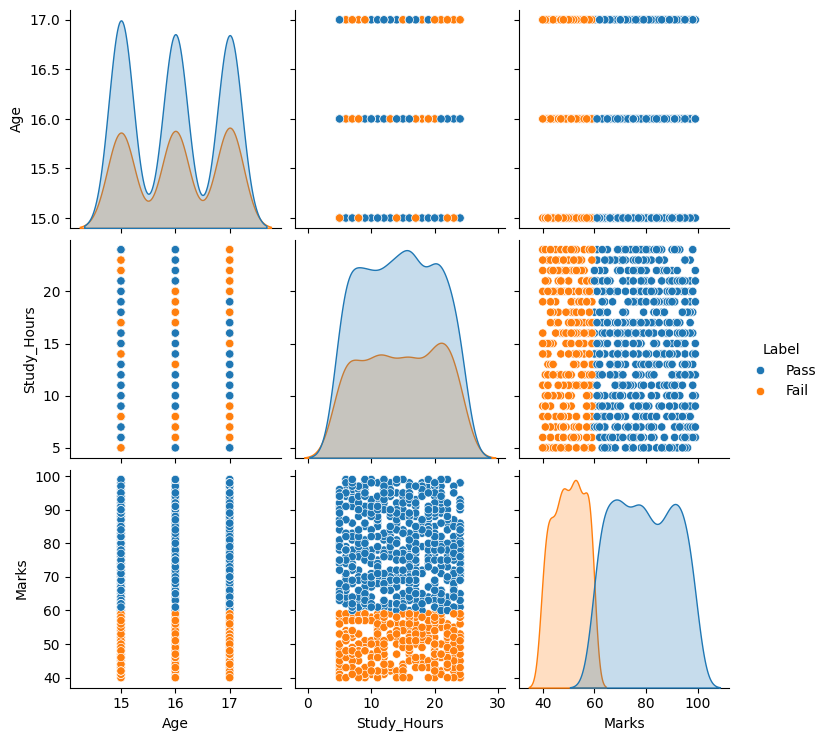

In [ ]:
#plot distribution of all features in data
sns.pairplot(df_students, hue='Label')

<Axes: xlabel='Label', ylabel='count'>

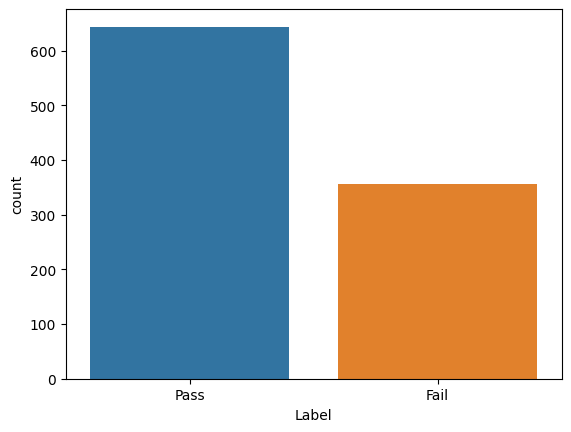

In [ ]:
#plot the counts of label
sns.countplot(x='Label', data=df_students,hue='Label')

##Creating Features and Target Variable data frames

In [ ]:
X = df_students.drop('Label', axis=1)
y = df_students['Label']

##Feature Engineering (Scaling/Encoding)

1.   Min/Max or Standardize scaling for numerical features
2.   Encoding for categorical feature (In this case target variable)



In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Gender                      1000 non-null   object
 1   Age                         1000 non-null   int64 
 2   Study_Hours                 1000 non-null   int64 
 3   Attendance                  1000 non-null   object
 4   Parent_Education            1000 non-null   object
 5   Extracurricular_Activities  1000 non-null   object
 6   Marks                       1000 non-null   int64 
 7   School_Type                 1000 non-null   object
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: Label
Non-Null Count  Dtype 
--------------  ----- 
1000 non-null   object
dtypes: object(1)
memory usage: 7.9+ KB


In [ ]:
#seperate numerical and categorical features from data into two variables
x_numerical_df=X.select_dtypes(include=['float64', 'int64'])
x_categorical_df=X.select_dtypes(include=['object'])

In [ ]:
#scale the features and encode the target varaible
x_scaler = MinMaxScaler()
x_numercial_scaled = x_scaler.fit_transform(x_numerical_df)
x_oe = OneHotEncoder()
x_categorical_encoded = x_oe.fit_transform(x_categorical_df).astype('int')
y_le=LabelEncoder()
y_encoded = y_le.fit_transform(y)

In [ ]:
# Convert the encoded array to a DataFrame with column names
encoded_columns = x_oe.get_feature_names_out(x_categorical_df.columns)
encoded_df = pd.DataFrame(x_categorical_encoded.toarray(), columns=encoded_columns)

In [ ]:
#combine numerical and categorical to create new data frame containing the column names from actual data
scaled_df = pd.DataFrame(x_numercial_scaled, columns=x_numerical_df.columns)

In [ ]:
#now make one data frame
X_engineered=pd.concat([encoded_df,scaled_df], axis=1)

In [ ]:
X_engineered.head()

,Gender_Female,Gender_Male,Attendance_High,Attendance_Low,Attendance_Medium,Parent_Education_College,Parent_Education_Graduate,Parent_Education_High School,Extracurricular_Activities_No,Extracurricular_Activities_Yes,School_Type_Private,School_Type_Public,Age,Study_Hours,Marks
0,0,1,1,0,0,0,0,1,0,1,1,0,0.5,1.000000,0.084746
1,1,0,1,0,0,0,1,0,0,1,1,0,1.0,0.631579,0.779661
2,0,1,0,0,1,1,0,0,0,1,0,1,0.0,1.000000,0.271186
3,0,1,0,1,0,1,0,0,0,1,0,1,0.5,0.052632,0.050847
4,0,1,0,1,0,0,0,1,0,1,1,0,1.0,0.105263,0.355932


##Spliting data into training and testing

In [ ]:
#split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_engineered,y_encoded, test_size=0.2, random_state=42)

##KNN - Classifier

**Identify best values of k between 1 to 9**

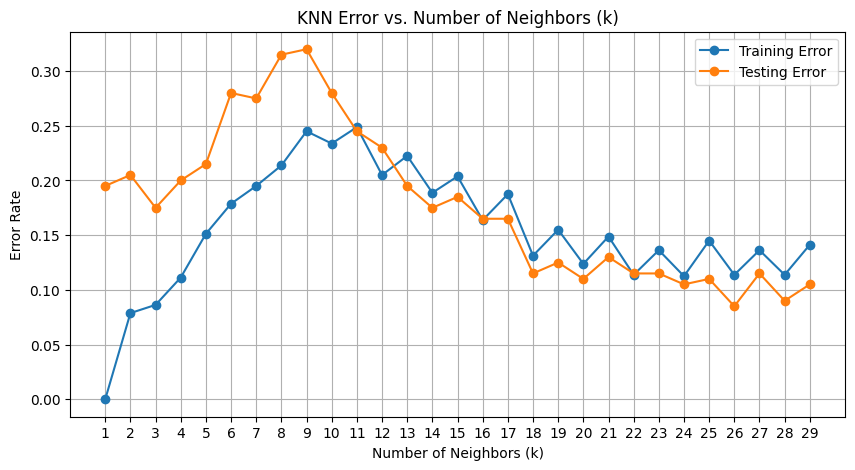

In [ ]:
# Initialize lists to store the errors
k_values = range(1, 30)
train_errors = []
test_errors = []

# Iterate over k values
for k in k_values:
    # Create and fit the KNN model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Predict on training and testing sets
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate the accuracy and errors
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Append the error (1 - accuracy)
    train_errors.append(1 - train_accuracy)
    test_errors.append(1 - test_accuracy)

# Plotting the errors
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_errors, label='Training Error', marker='o')
plt.plot(k_values, test_errors, label='Testing Error', marker='o')
plt.title('KNN Error vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Error Rate')
plt.xticks(k_values)
plt.legend()
plt.grid()
plt.show()

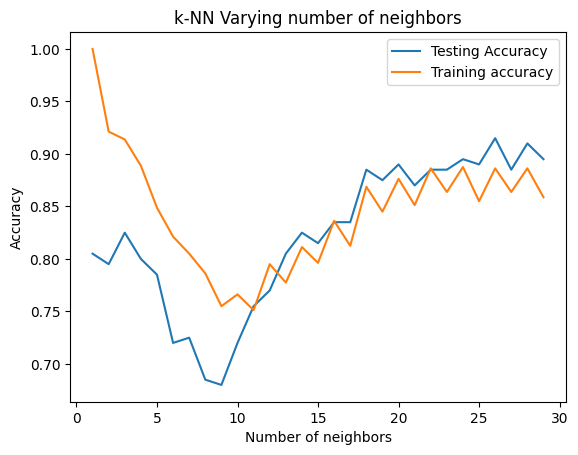

In [ ]:
#Setup arrays to store training and test accuracies
neighbors = np.arange(1,30)
train_accuracy =np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

for i,k in enumerate(neighbors):
    #Setup a knn classifier with k neighbors
    knn = KNeighborsClassifier(n_neighbors=k)

    #Fit the model
    knn.fit(X_train, y_train)

    #Compute accuracy on the training set
    train_accuracy[i] = knn.score(X_train, y_train)

    #Compute accuracy on the test set
    test_accuracy[i] = knn.score(X_test, y_test)
#plot accuracies
plt.title('k-NN Varying number of neighbors')
plt.plot(neighbors, test_accuracy, label='Testing Accuracy')
plt.plot(neighbors, train_accuracy, label='Training accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')
plt.show()

**From the graph, at 3 neigbours the training and testing accuracy seems good. Apply KNN With 3-Neighbours**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

**Test the classifier**

In [ ]:
y_pred = knn.predict(X_test)

**Calculate accuracy**

In [ ]:
accuracy_1=accuracy_score(y_test, y_pred)*100
print(f'Accuracy with 1 neigbour : {accuracy_1} %')

Accuracy with 1 neigbour : 82.5 %


**Create confusion matrix manually**


In [ ]:
pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'], margins=True)

Predicted,0,1,All
Actual,,,
0,38,20,58
1,15,127,142
All,53,147,200


**Create confusion matrix with scikit-learn**

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 38,  20],
       [ 15, 127]])

**Visualize confusion matrix**

Text(50.722222222222214, 0.5, 'Actual')

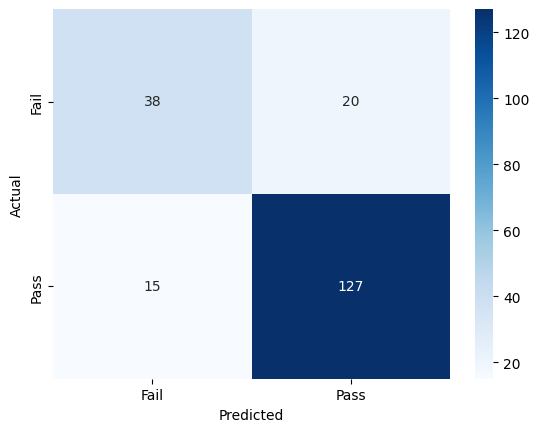

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=df_students['Label'].sort_values().unique(), yticklabels=df_students['Label'].sort_values().unique())
plt.xlabel('Predicted')
plt.ylabel('Actual')

**Create classification report**

In [ ]:
#create classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.66      0.68        58
           1       0.86      0.89      0.88       142

    accuracy                           0.82       200
   macro avg       0.79      0.77      0.78       200
weighted avg       0.82      0.82      0.82       200



**Hyperparameter Tuning (Optimization)**

So we have 1000 data points, taking square root to get max numbers of neighbour to avoid overfitting and underfitting

In [ ]:
#In case of classifier like knn the parameter to be tuned is n_neighbors
param_grid = {'n_neighbors':np.arange(1,30)}

In [ ]:
knn = KNeighborsClassifier()
knn_cv= GridSearchCV(knn,param_grid,cv=10)
knn_cv.fit(X_engineered,y_encoded)

/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])})

In [ ]:
print(f'Best Accuracy {(knn_cv.best_score_)*100:.02f} %')

Best Accuracy 84.50 %


In [ ]:
print(f'Best value of k {knn_cv.best_params_}')

Best value of k {'n_neighbors': 28}


**Out of sample testing or Deployment to production (New data provided to algorithm)**

In [ ]:
new_data = {
    "Gender": "Female",
    "Age": 17,
    "Study_Hours": 10,
    "Attendance": "High",
    "Parent_Education": "College",
    "Extracurricular_Activities": "Yes",
    "Marks": 72,
    "School_Type": "Public",
}

new_df = pd.DataFrame([new_data])
new_df


,Gender,Age,Study_Hours,Attendance,Parent_Education,Extracurricular_Activities,Marks,School_Type
0,Female,17,10,High,College,Yes,72,Public


In [ ]:
new_data=pd.concat([new_df,X],axis=0)

In [ ]:
new_data_num=new_data.select_dtypes(include=['float64', 'int64'])
new_data_cat=new_data.select_dtypes(include=['object'])

In [ ]:
# Define transformations for each column type
preprocessor = ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(),new_data_cat.columns),
        ('num',MinMaxScaler(),new_data_num.columns)  # Scaling numeric columns
    ])

# Apply transformations to the DataFrame
transformed_data = preprocessor.fit_transform(new_data)

# Convert the transformed data to a DataFrame
transformed_df = pd.DataFrame(
    transformed_data,
    columns=(preprocessor.named_transformers_['cat'].get_feature_names_out(new_data_cat.columns).tolist()+
        preprocessor.named_transformers_['num'].get_feature_names_out(new_data_num.columns).tolist()

))

In [ ]:
transformed_df.columns

Index(['Gender_Female', 'Gender_Male', 'Attendance_High', 'Attendance_Low',
       'Attendance_Medium', 'Parent_Education_College',
       'Parent_Education_Graduate', 'Parent_Education_High School',
       'Extracurricular_Activities_No', 'Extracurricular_Activities_Yes',
       'School_Type_Private', 'School_Type_Public', 'Age', 'Study_Hours',
       'Marks'],
      dtype='object')

In [ ]:
new_prediction = knn_cv.predict(transformed_df.iloc[[0]])

In [ ]:
if(new_prediction[0]==1):
  print('The Student is Pass')
else:
  print('The Student is Failed')

The Student is Pass
